In [39]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline #imblearn for using smote in pipeline so we are using this one
from sklearn.preprocessing import OneHotEncoder

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# EDA

In [42]:
full_df = pd.read_csv('train.csv')
full_df.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [43]:
full_df.describe()

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177
std,181865.479132,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939
min,0.000000,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,157499.750000,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000
50%,314999.500000,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000
75%,472499.250000,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000
max,629999.000000,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


In [44]:
full_df.shape

(630000, 21)

In [45]:
#Taking sample data. becose we have huse dataset 
df = full_df.sample(20000, random_state=42)
df.shape

(20000, 21)

In [46]:
df.Irrigation_Need.value_counts()       

Irrigation_Need
Low       11761
Medium     7574
High        665
Name: count, dtype: int64

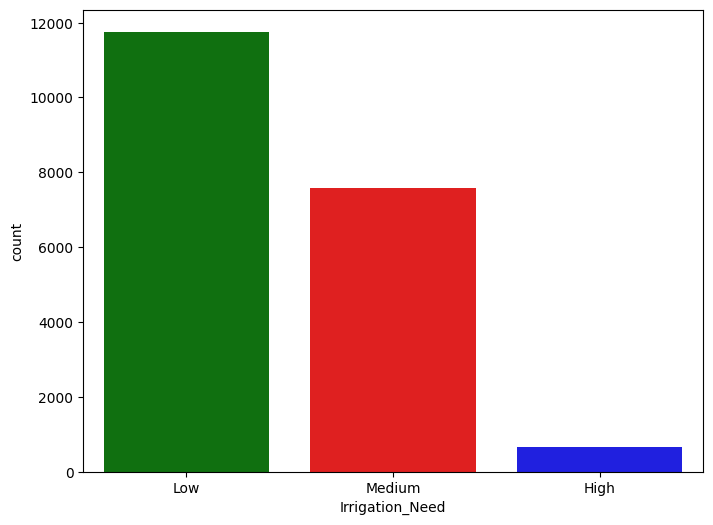

In [47]:
plt.figure(figsize = (8,6))
sns.countplot(x=df['Irrigation_Need'], palette=['green','red','blue'])
plt.show()

In [48]:
df.isna().sum()

id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

In [49]:
#Missing values in percentage
df.isna().sum()/df.shape[0]*100

id                         0.0
Soil_Type                  0.0
Soil_pH                    0.0
Soil_Moisture              0.0
Organic_Carbon             0.0
Electrical_Conductivity    0.0
Temperature_C              0.0
Humidity                   0.0
Rainfall_mm                0.0
Sunlight_Hours             0.0
Wind_Speed_kmh             0.0
Crop_Type                  0.0
Crop_Growth_Stage          0.0
Season                     0.0
Irrigation_Type            0.0
Water_Source               0.0
Field_Area_hectare         0.0
Mulching_Used              0.0
Previous_Irrigation_mm     0.0
Region                     0.0
Irrigation_Need            0.0
dtype: float64

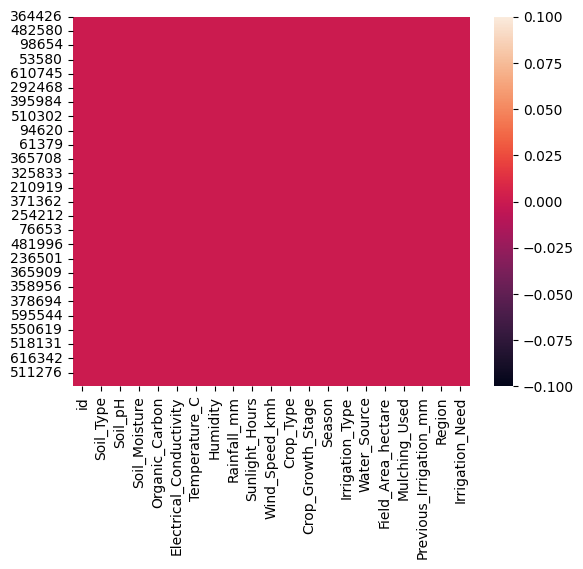

In [50]:
#Show null values 
sns.heatmap(df.isna())
plt.show()

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 364426 to 567372
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       20000 non-null  int64  
 1   Soil_Type                20000 non-null  object 
 2   Soil_pH                  20000 non-null  float64
 3   Soil_Moisture            20000 non-null  float64
 4   Organic_Carbon           20000 non-null  float64
 5   Electrical_Conductivity  20000 non-null  float64
 6   Temperature_C            20000 non-null  float64
 7   Humidity                 20000 non-null  float64
 8   Rainfall_mm              20000 non-null  float64
 9   Sunlight_Hours           20000 non-null  float64
 10  Wind_Speed_kmh           20000 non-null  float64
 11  Crop_Type                20000 non-null  object 
 12  Crop_Growth_Stage        20000 non-null  object 
 13  Season                   20000 non-null  object 
 14  Irrigation_Type      

# Preprocessing

In [52]:
data=df.drop(["id"],axis=1)

In [53]:
X = data.iloc[:,:-1]
print(X.head())
print('\n',X.dtypes)

       Soil_Type  Soil_pH  Soil_Moisture  Organic_Carbon  \
364426     Sandy     4.87          38.18            1.37   
224752     Loamy     5.89          49.28            1.39   
110423     Sandy     6.44          50.75            1.16   
272555      Silt     4.84          49.17            0.85   
199651     Sandy     5.82          44.72            0.41   

        Electrical_Conductivity  Temperature_C  Humidity  Rainfall_mm  \
364426                     0.29          21.43     83.74      2082.14   
224752                     3.11          22.91     44.62      1864.00   
110423                     0.24          39.88     68.89      1194.07   
272555                     2.26          20.94     55.12      2033.44   
199651                     0.81          41.49     41.30      2223.23   

        Sunlight_Hours  Wind_Speed_kmh  Crop_Type Crop_Growth_Stage Season  \
364426            7.09           16.51     Cotton           Harvest   Zaid   
224752           10.39            9.46  Suga

In [54]:
y = data['Irrigation_Need']
print(y)

364426       Low
224752       Low
110423       Low
272555    Medium
199651       Low
           ...  
319053    Medium
509307       Low
264453       Low
529439       Low
567372       Low
Name: Irrigation_Need, Length: 20000, dtype: object


In [55]:
y.unique()

array(['Low', 'Medium', 'High'], dtype=object)

In [56]:
y=y.replace({
    "Low":0,
    "Medium":1,
    "High":2
})

In [57]:
new_X=X[['Soil_Moisture','Temperature_C','Wind_Speed_kmh', 'Rainfall_mm', 'Crop_Growth_Stage']]
new_X

,Soil_Moisture,Temperature_C,Wind_Speed_kmh,Rainfall_mm,Crop_Growth_Stage
364426,38.18,21.43,16.51,2082.14,Harvest
224752,49.28,22.91,9.46,1864.00,Harvest
110423,50.75,39.88,15.52,1194.07,Harvest
272555,49.17,20.94,19.58,2033.44,Flowering
199651,44.72,41.49,8.99,2223.23,Sowing
...,...,...,...,...,...
319053,58.25,41.87,6.57,1574.74,Vegetative
509307,56.57,16.07,9.11,2351.41,Flowering
264453,52.79,18.37,6.32,2140.29,Harvest
529439,11.55,15.67,9.92,1571.39,Sowing


In [58]:
#Splitting data into Train and Test sets

X_train,X_test,y_train,y_test=train_test_split(new_X,y,test_size=0.2,random_state=42)

In [59]:
num = X_train.select_dtypes(exclude="object").columns
print(num)

Index(['Soil_Moisture', 'Temperature_C', 'Wind_Speed_kmh', 'Rainfall_mm'], dtype='object')


In [60]:
cat = X_train.select_dtypes(include = 'object').columns
print(cat)

Index(['Crop_Growth_Stage'], dtype='object')


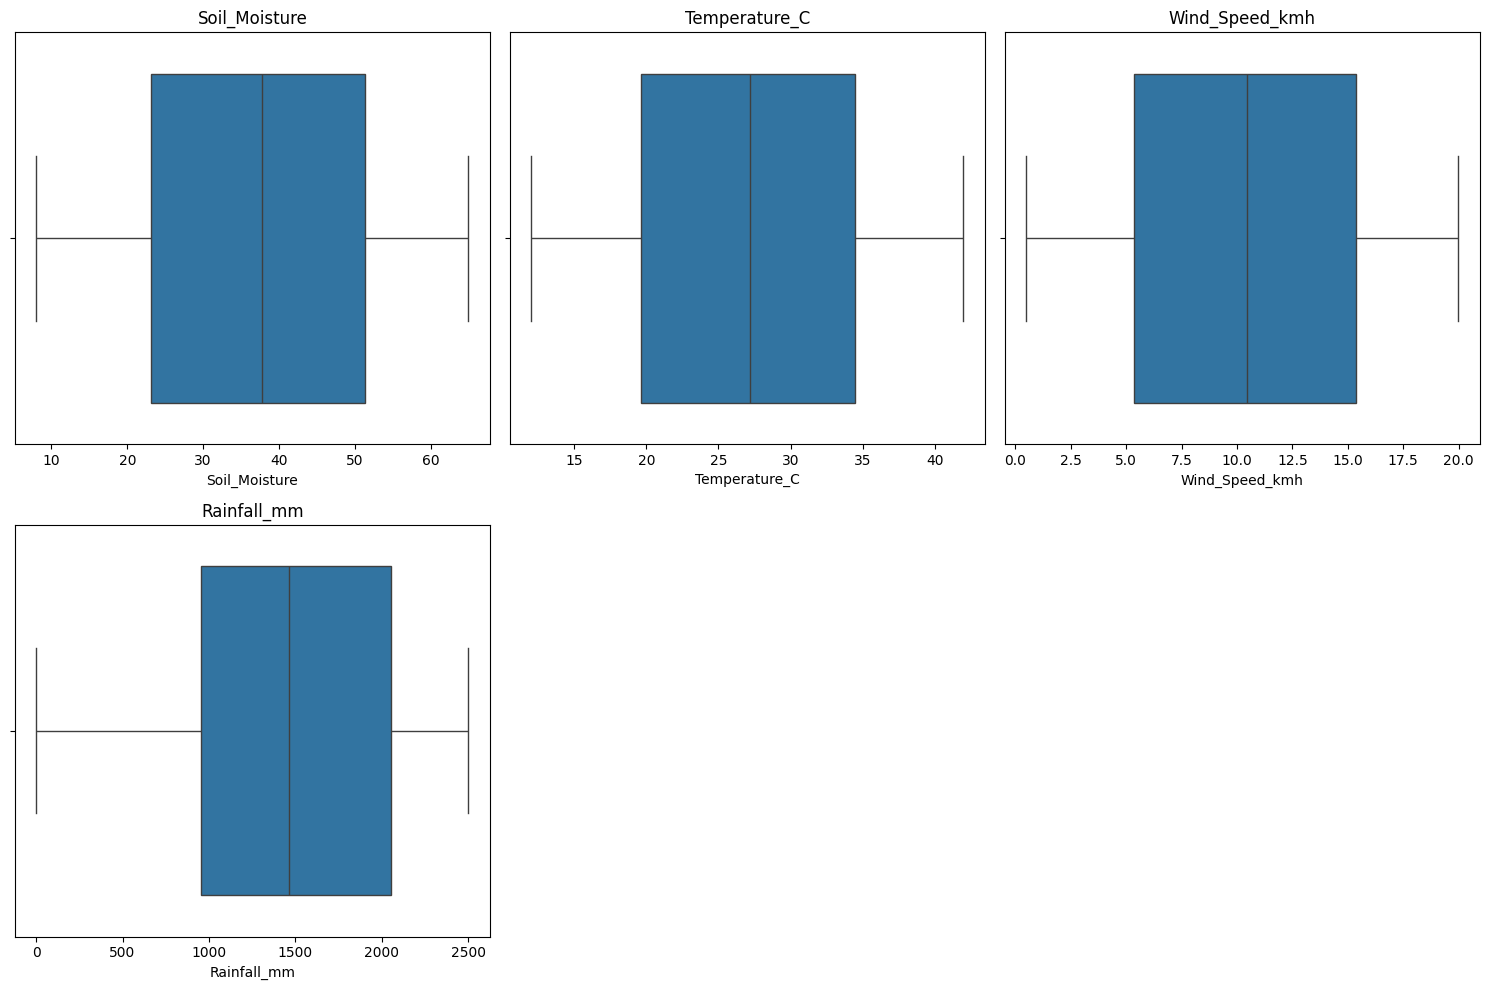

In [61]:
#Boxplot - to - identify outliers

n = len(num)

plt.figure(figsize=(15, 10))

for i, col in enumerate(num):
    plt.subplot((n//3)+1, 3, i+1)  # 3 columns layout
    sns.boxplot(data=X_train, x=col)
    plt.title(col)

plt.tight_layout()
plt.show()

In [62]:
#Correlation Heatmap

con = pd.concat([X_train, y_train],axis=1)
data_corr = con.corr(numeric_only=True)[["Irrigation_Need"]].sort_values( by="Irrigation_Need", ascending=True)
print(data_corr)

                 Irrigation_Need
Soil_Moisture          -0.458771
Rainfall_mm            -0.111839
Wind_Speed_kmh          0.246223
Temperature_C           0.247770
Irrigation_Need         1.000000


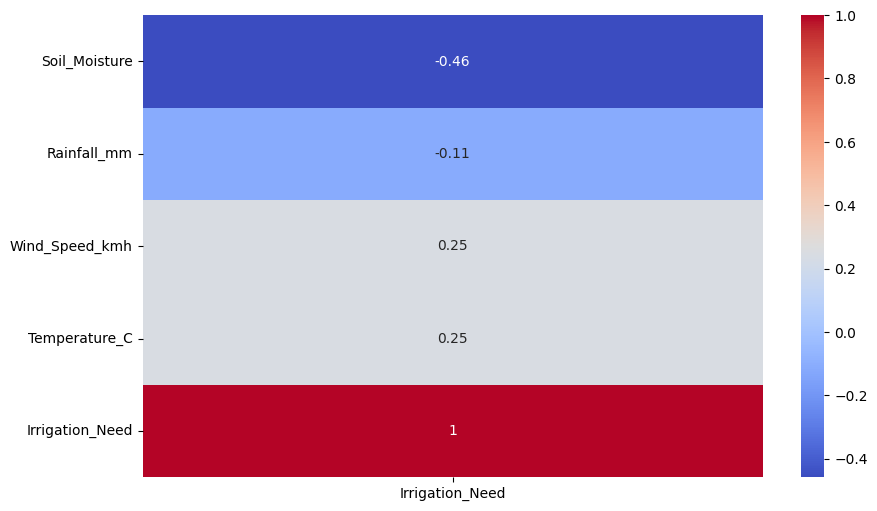

In [63]:
plt.figure(figsize = (10,6))
sns.heatmap(data_corr, annot=True, cmap='coolwarm')
plt.show()

In [64]:
from sklearn.preprocessing import MinMaxScaler
pipe_num = Pipeline([
    ('scaler',MinMaxScaler())
])
pipe_num

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [65]:

pipe_cat = Pipeline([
    ('encode',OneHotEncoder(handle_unknown="ignore"))
])

pipe_cat

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('encode', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",True
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifi

In [66]:
#Combine into a Column Transformer
from sklearn.compose import ColumnTransformer
processer =ColumnTransformer([
    ('num',pipe_num,num),
    ('cat',pipe_cat,cat)
])
processer

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [67]:
X_train_processed = processer.fit_transform(X_train)

X_test_processed = processer.transform(X_test)

In [68]:
#!pip install imbalanced-learn

In [69]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

In [70]:
#Selecting Important features with selectKBest way

from sklearn.feature_selection import SelectKBest,f_classif, chi2, mutual_info_classif

# selector
selector = SelectKBest(
    score_func=f_classif,
    k=15
)

# fit selector
selector.fit(X_train_smote, y_train_smote)

# transformed feature names
feature_names = processer.get_feature_names_out()

#scores of all features
scores = selector.scores_

#mask for selected features
mask = selector.get_support()

# selected feature names 
selected_features = feature_names[mask]

#selected feature scores
selected_scores = scores[mask]

#created a DataFrame
feature_scores = pd.DataFrame({
    'Feature': selected_features,
    'Score': selected_scores})

#sort by score descending
feature_scores = feature_scores.sort_values(
    by= 'Score', ascending=False)

print("Top Selected Features:")
print(f"{'Index':<8}{'Feature':<45}{'Score'}")
print('-'*70)
a=[]
for i, (f,s) in enumerate(zip(selected_features, selected_scores), start=1):
    print(f'{i:<8}{f:<45}{s:.2f}')
    

Top Selected Features:
Index   Feature                                      Score
----------------------------------------------------------------------
1       num__Soil_Moisture                           9051.28
2       num__Temperature_C                           3888.42
3       num__Wind_Speed_kmh                          2526.31
4       num__Rainfall_mm                             1970.42
5       cat__Crop_Growth_Stage_Flowering             1615.35
6       cat__Crop_Growth_Stage_Harvest               2683.73
7       cat__Crop_Growth_Stage_Sowing                2467.93
8       cat__Crop_Growth_Stage_Vegetative            1317.20


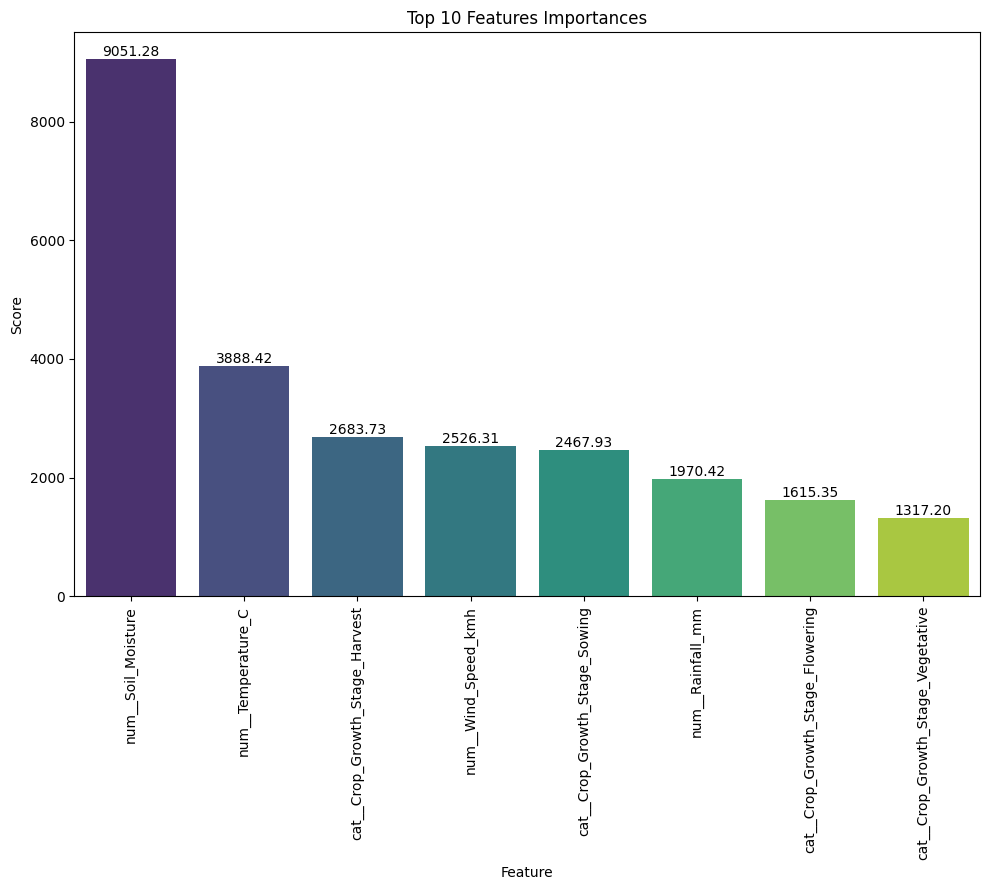

In [71]:
#plot for imp features
plt.figure(figsize =(10,9))
ax=sns.barplot(data=feature_scores.head(10), x='Feature', y='Score',palette='viridis')
for container in ax.containers:
    ax.bar_label(container,fmt='%.2f')
plt.xticks(rotation=90)
plt.title('Top 10 Features Importances')
plt.tight_layout()
plt.show()

In [72]:
print(y.value_counts())

Irrigation_Need
0    11761
1     7574
2      665
Name: count, dtype: int64


In [73]:
print(y_train_smote.value_counts())

Irrigation_Need
0    9407
1    9407
2    9407
Name: count, dtype: int64


In [ ]:


models = {

    'LogisticRegression': (
        LogisticRegression(),
        {
            'model__C': [0.01, 0.1, 1, 10],
            'model__class_weight': ['balanced'],
            'model__solver': ['lbfgs','saga']
        }
    ),

    'K_Neighbors': (
        KNeighborsClassifier(),
        {
            'model__n_neighbors': [3, 5, 7],
            'model__weights': ['uniform', 'distance'],
            'model__metric': ['euclidean', 'manhattan']
        }
    ),

    'DecisionTree': (
        DecisionTreeClassifier(),
        {
            'model__criterion': ['gini', 'entropy'],
            'model__max_depth': [None, 5, 10, 20],
            'model__min_samples_split': [2, 5, 10],
            'model__min_samples_leaf': [1, 2, 4]
        }
    ),

    'SVC': (
        SVC(),
        {
            'model__kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
            'model__C': [0.01, 0.1, 1, 10],
            'model__gamma': ['scale', 'auto'],
            'model__class_weight': ['balanced']
        }
    ),

    'NaiveBayesG': (
        GaussianNB(),
        {
            'model__var_smoothing': [1e-9, 1e-8, 1e-7]
        }
    ),

    'NaiveBayesM': (
        MultinomialNB(),
        {
            'model__alpha': [0.1, 1.0, 10]
        }
    ),

    'NaiveBayesB': (
        BernoulliNB(),
        {
            'model__alpha': [0.1, 1.0, 10]
        }
    ),

    'RandomForestC': (
        RandomForestClassifier(),
        {
            'model__n_estimators': [100, 200],
            'model__max_depth': [5, 10, None],
            'model__min_samples_split': [2, 5],
            'model__min_samples_leaf': [1, 2],
            'model__max_features': ['sqrt', 'log2'],
            'model__class_weight': ['balanced']
        }
    ),

    'GradientBoosting': (
        GradientBoostingClassifier(),
        {
            'model__n_estimators': [50, 100],
            'model__learning_rate': [0.05, 0.1]
        }
    ),

    'XGBoost': (
        XGBClassifier(
            objective='multi:softprob',
            eval_metric='mlogloss'
        ),
        {
            'model__n_estimators': (50, 300),
            'model__max_depth': (3, 12),
            'model__learning_rate': (0.01, 0.3, 'log-uniform'),
            'model__subsample': (0.5, 1.0, 'uniform'),
            'model__colsample_bytree': (0.5, 1.0, 'uniform'),
            'model__gamma': (0, 5),
            'model__min_child_weight': (1, 10)
        }
    )
}

models = {'LogisticRegression': LogisticRegression(),
          'K_Neighbors':  KNeighborsClassifier(),
          'DecisionTree': DecisionTreeClassifier(),
          'SVC': SVC(),
          'NaiveBayesG': GaussianNB(),
          'RandomForestC': RandomForestClassifier(),
          'GradientBoosting': GradientBoostingClassifier(),
          'XGBoost': XGBClassifier()
         }
          
          
          
          

In [75]:
results = {}

for name, (model, params) in models.items():

    pipe = Pipeline([
        ("model", model)
    ])

    random = RandomizedSearchCV(
        pipe,
        params,
        n_iter=5,
        cv=3,
        scoring='accuracy',
        n_jobs=-1,
        random_state=42,
        verbose=1
    )

    # train
    random.fit(X_train_smote, y_train_smote)

    # predict
    y_pred = random.best_estimator_.predict(
        X_test_processed
    )

    # accuracy
    accuracy = accuracy_score(y_test, y_pred)

    # store results
    results[name] = {
        'accuracy': accuracy,
        'best_params': random.best_params_
    }

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Fitting 3 folds for each of 5 candidates, totalling 15 fits


In [76]:
#sort and print results
results_sorted = dict(sorted(results.items(), key = lambda item: item[1]['accuracy'], reverse = True))
for model,result in results_sorted.items():
    print(f"{model}:Accuracy={result['accuracy']:.5f}, Best Params = {result['best_params']}")

RandomForestC:Accuracy=0.90025, Best Params = {'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': None, 'model__class_weight': 'balanced'}
GradientBoosting:Accuracy=0.89525, Best Params = {'model__n_estimators': 100, 'model__learning_rate': 0.1}
XGBoost:Accuracy=0.88825, Best Params = {'model__subsample': 0.5, 'model__n_estimators': 50, 'model__min_child_weight': 1, 'model__max_depth': 12, 'model__learning_rate': 0.3, 'model__gamma': 0, 'model__colsample_bytree': 1.0}
DecisionTree:Accuracy=0.88675, Best Params = {'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_depth': 10, 'model__criterion': 'entropy'}
K_Neighbors:Accuracy=0.86325, Best Params = {'model__weights': 'distance', 'model__n_neighbors': 5, 'model__metric': 'manhattan'}
SVC:Accuracy=0.85050, Best Params = {'model__kernel': 'rbf', 'model__gamma': 'scale', 'model__class_weight': 'balanced', 'model__C': 1}
LogisticR

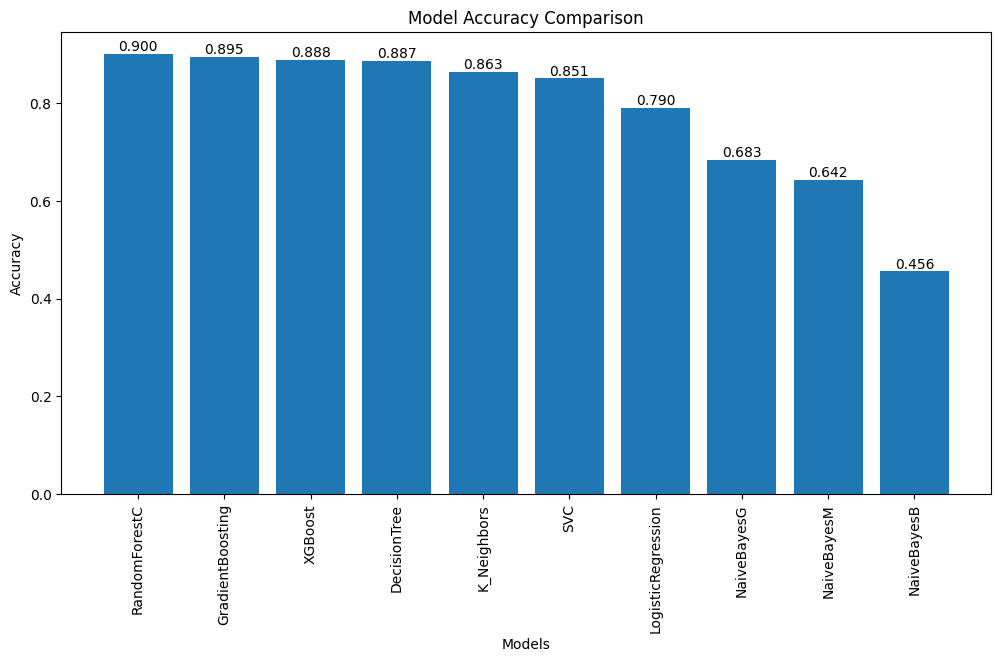

In [77]:
# model names with accuracy score in plot
models = list(results_sorted.keys())
accuracy = [results_sorted[M]['accuracy'] for M in models]

# plot
plt.figure(figsize=(12,6))

bars=plt.bar(models,accuracy)

# labels
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
# rotate model names
plt.xticks(rotation=90)

# ✅ add scores on top of bars
for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f"{y:.3f}",
        ha='center',
        va='bottom'
    )

plt.show()

In [78]:
#Now work with total dataset
x=full_df[['Soil_Moisture','Temperature_C','Wind_Speed_kmh', 'Rainfall_mm', 'Crop_Growth_Stage']]

In [79]:
x

,Soil_Moisture,Temperature_C,Wind_Speed_kmh,Rainfall_mm,Crop_Growth_Stage
0,32.58,15.01,16.79,725.99,Sowing
1,56.61,22.92,3.39,985.66,Vegetative
2,27.71,26.97,3.85,2201.70,Vegetative
3,13.32,13.32,2.31,1357.33,Flowering
4,59.14,20.22,13.94,1538.20,Sowing
...,...,...,...,...,...
629995,13.45,26.65,18.85,1041.33,Sowing
629996,54.49,36.99,17.99,1419.57,Vegetative
629997,11.98,37.82,17.25,88.45,Vegetative
629998,42.86,34.99,5.00,2433.92,Vegetative


In [80]:
Y=full_df.iloc[:,-1]

In [81]:
Y=Y.replace({
    "Low":0,
    "Medium":1,
    "High":2
})

In [82]:
Y

0         0
1         0
2         0
3         1
4         0
         ..
629995    1
629996    1
629997    2
629998    0
629999    0
Name: Irrigation_Need, Length: 630000, dtype: int64

In [83]:
m_train_raw,m_test_raw,n_train,n_test=train_test_split(x,Y,random_state=42,test_size=0.2)
m_train = processer.fit_transform(m_train_raw)
m_test = processer.transform(m_test_raw)



In [84]:
datasets = {
    "m_train": m_train,
    "m_test": m_test,
    "n_train": n_train,
    "n_test": n_test
}

for name, data in datasets.items():
    print(f"Shape of {name} = {data.shape}")

Shape of m_train = (504000, 8)
Shape of m_test = (126000, 8)
Shape of n_train = (504000,)
Shape of n_test = (126000,)


In [85]:

m_train_smote, n_train_smote = smote.fit_resample(
    m_train,
    n_train
)

In [86]:
n_train.value_counts()

Irrigation_Need
0    296180
1    191060
2     16760
Name: count, dtype: int64

In [87]:
n_train_smote.value_counts()

Irrigation_Need
0    296180
2    296180
1    296180
Name: count, dtype: int64

In [88]:
# Get feature names AFTER fit_transform on the full training split
feature_names = processer.get_feature_names_out()

# Now build the DataFrame safely
m_train_df = pd.DataFrame(m_train, columns=feature_names)
m_test_df  = pd.DataFrame(m_test,  columns=feature_names)

In [ ]:
#final model
final_model = RandomForestClassifier(
    n_estimators=100,
    min_samples_split= 2,
    min_samples_leaf= 1,
    max_features= 'log2',
    max_depth= None,
    class_weight= 'balanced',
    random_state=42,
)


final_model.fit(m_train_smote, n_train_smote)

#predict and score on dataframe 

Y_predict=final_model.predict(m_test)


In [91]:
print(
    accuracy_score(n_test, Y_predict)
)

0.9003412698412698


In [92]:
train_acc=final_model.score(m_train,n_train)
test_acc=final_model.score(m_test,n_test)
gap = train_acc - test_acc

print(f'Train Accuracy : {train_acc:.4f}')
print(f'Test Accuracy : {test_acc:.4f}')
print(f'Gap  : {gap:.4f}')

if train_acc < 0.75:
    print('High Bias - Model is Underfitting')
    print('Try: more features , complex model, remove regularization')

elif gap > 0.10:
    print ('High Variance - model is Overfitting')
    print ('Try: more data, regularization, reduce features, simpler model')

else:
    print('Good Fit')


Train Accuracy : 0.9304
Test Accuracy : 0.9003
Gap  : 0.0300
Good Fit


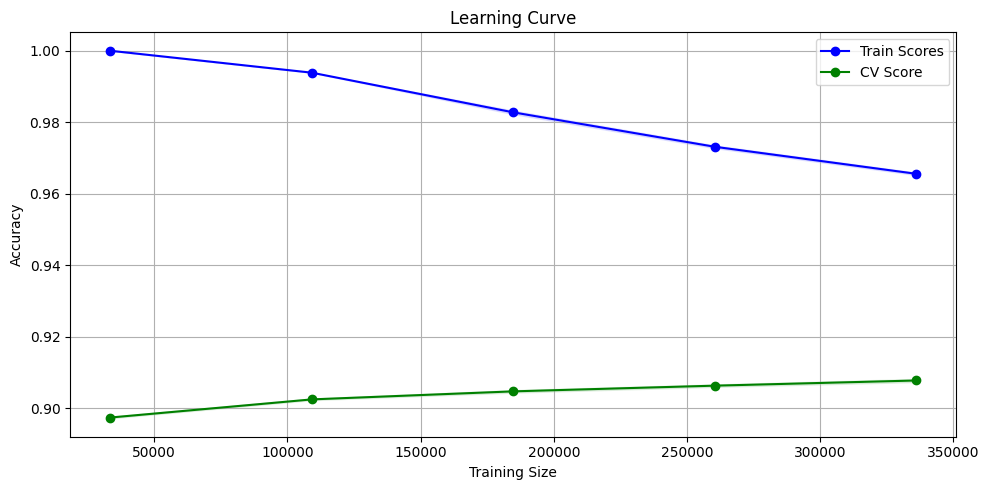

In [96]:
#Learning Curve 
from sklearn.model_selection import learning_curve, validation_curve

train_sizes, train_scores, test_scores = learning_curve(final_model, m_train, n_train, cv=3, scoring='accuracy', 
                                                        train_sizes = np.linspace(0.1, 1.0, 5), n_jobs=1)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

plt.figure(figsize = (10,5))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Train Scores')
plt.plot(train_sizes, test_mean, 'o-', color ='green', label='CV Score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='green')
plt.title('Learning Curve')
plt.xlabel('Training Size')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [97]:
#Save the Model
import joblib
joblib.dump(final_model,'model.pkl')
joblib.dump(processer,'preprocessor.pkl')

['preprocessor.pkl']

In [98]:
#Predict New Data
model = joblib.load('model.pkl')
preprocessor = joblib.load("preprocessor.pkl")


new_data= pd.DataFrame({
    'Soil_Moisture':[32.58],
    'Temperature_C':[15.01],
    'Wind_Speed_kmh':[16.79],
    'Rainfall_mm':[725.99],
    'Crop_Growth_Stage':['Sowing']
})

# Transform complete dataframe
new_data_processed = preprocessor.transform(new_data)

#Predict
prediction = model.predict(new_data_processed)

#Reverce mapping
reverse_map = {
    0: 'Low',
    1: 'Medium',
    2: 'High'
}


final_output = [reverse_map[i] for i in prediction]

print("Encoded Prediction:", prediction)
print("Final Prediction:", final_output)

Encoded Prediction: [0]
Final Prediction: ['Low']
